<p align="center"><a href="https://www.plus2net.com/python/pandas-dataframe-plot-pie.php"><img src="https://www.plus2net.com/images/top2.jpg" alt="plus2net Python Tutorials" width="300"></a></p>

# Pandas Pie Charts: Show Shares of a Meaningful Total

**Pandas Tutorial Series — Plotting**

[Read the tutorial](https://www.plus2net.com/python/pandas-dataframe-plot-pie.php)

Run cells from top to bottom. Save a copy in Drive to keep your changes. Pandas and Matplotlib are available in Colab. All datasets are synthetic and embedded. Compare the charts with the checks, then try the exercise before its solution. The export cell creates a PNG in the runtime; download it through Colab's Files sidebar. No external dataset or database is required.

## Create a Pie Chart from One Numeric Column

A pie shows each value as a share of the sum of the plotted values. Supply <code>y="MATH"</code> to select the numeric column. Without explicit labels or a named index, the slices use row labels. This small student example demonstrates the API; the sales example below gives a more natural part-of-whole use.

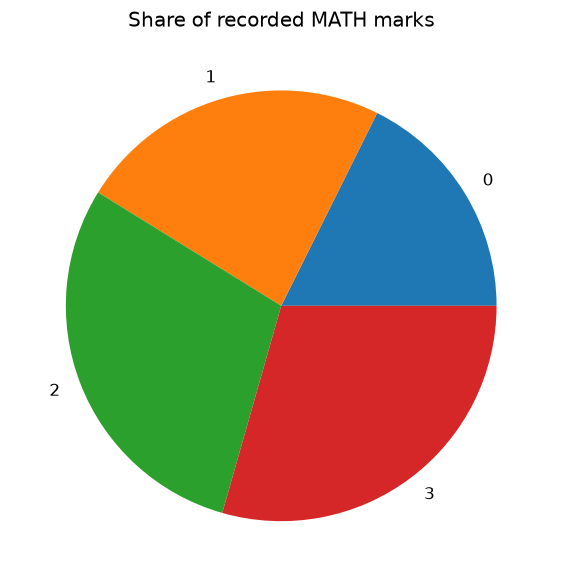

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def student_data():
    return pd.DataFrame({"NAME": ["Ravi", "Raju", "Alex", "Ronn"],
                         "MATH": [30, 40, 50, 50]})

df = student_data()
ax = df.plot.pie(y="MATH", title="Share of recorded MATH marks",
                 figsize=(5, 5), legend=False)
plt.tight_layout()
plt.show()
assert df["MATH"].sum() == 170

**What to check:** The denominator is 170 recorded marks, not a maximum possible exam score.

## Choose Figure Size and Font Size

<code>figsize</code> is a width-height pair in inches. Equal dimensions work well for a circular chart. <code>fontsize</code> controls the category-label text; percentage text can also be adjusted through <code>textprops</code>. Increase the figure size before making already crowded labels larger.

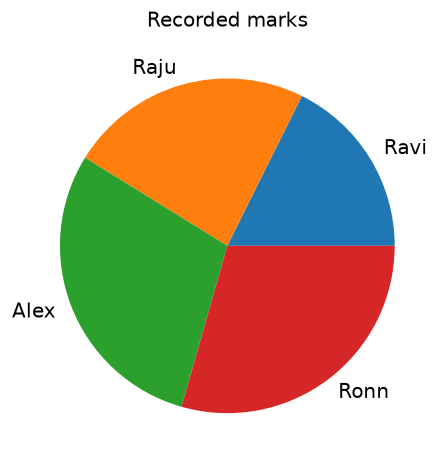

In [ ]:
df = student_data()
ax = df.plot.pie(y="MATH", title="Recorded marks", figsize=(4, 4),
                 fontsize=12, labels=df["NAME"].tolist(), legend=False)
plt.tight_layout()
plt.show()

## Use Category Names as Labels

A labels list must match the plotted values in length and order. Build it from the same DataFrame after any sorting or filtering. Alternatively, put the names in the index with <a href="https://www.plus2net.com/python/pandas-dataframe-set_index.php">set_index()</a>. Keep category names short enough to read.

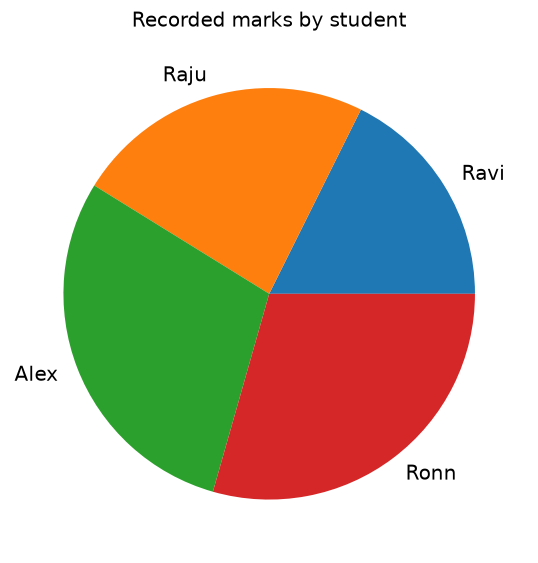

In [ ]:
df = student_data()
my_labels = df["NAME"].tolist()
ax = df.plot.pie(y="MATH", labels=my_labels, fontsize=12,
                 title="Recorded marks by student", legend=False)
plt.tight_layout()
plt.show()

## Control Label Distance and the Legend

<code>labeldistance</code> places labels at a fraction of the radius; 1.1 is outside the pie. You can suppress slice labels and use a legend with <code>labeldistance=None</code>. A legend is useful for longer category names, but readers still need clear colours and a small number of categories.

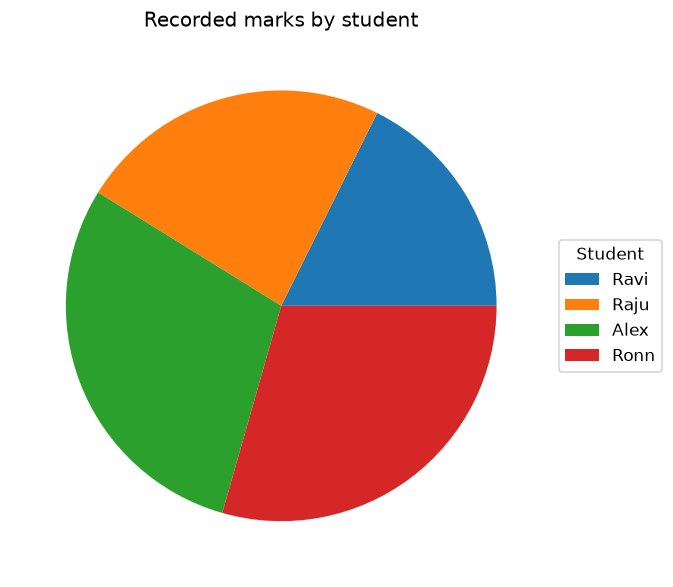

In [ ]:
df = student_data().set_index("NAME")
ax = df.plot.pie(y="MATH", labeldistance=None, legend=True,
                 figsize=(6, 5), title="Recorded marks by student")
ax.legend(title="Student", loc="center left", bbox_to_anchor=(1, 0.5))
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## autopct: Display Each Share as a Percentage

<code>autopct="%1.1f%%"</code> displays one decimal place; <code>%1.2f%%</code> displays two. Percentages are calculated from the plotted sum. Rounded labels may not add to exactly 100%. Do not interpret a student's share of total marks as their exam percentage.

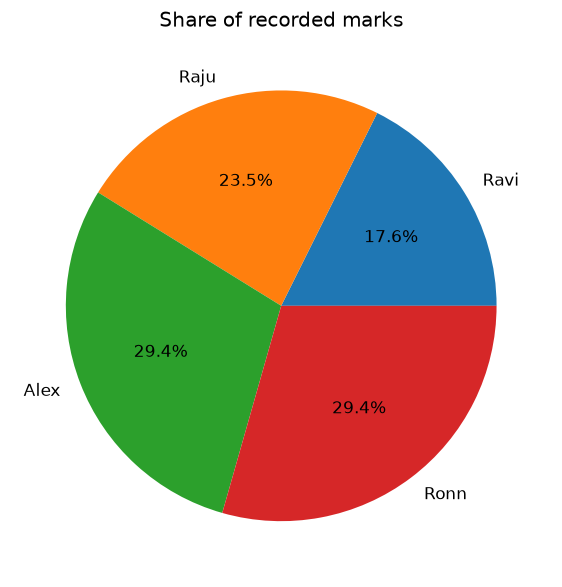

In [ ]:
df = student_data().set_index("NAME")
ax = df.plot.pie(y="MATH", autopct="%1.1f%%", legend=False,
                 figsize=(5, 5), title="Share of recorded marks")
ax.set_ylabel("")
plt.tight_layout()
plt.show()
print((df["MATH"] / df["MATH"].sum() * 100).round(1))

**Expected output**

```text
NAME
Ravi    17.6
Raju    23.5
Alex    29.4
Ronn    29.4
Name: MATH, dtype: float64
```

**What to check:** Ravi 17.6%, Raju 23.5%, Alex 29.4% and Ronn 29.4%.

## Assign Colours in the Same Order as the Slices

The pie option is <code>colors</code>. Supply one colour per category for a predictable mapping. Use named colours or hexadecimal values. If you sort the values, rebuild the colour list from the category names so the same category keeps its colour.

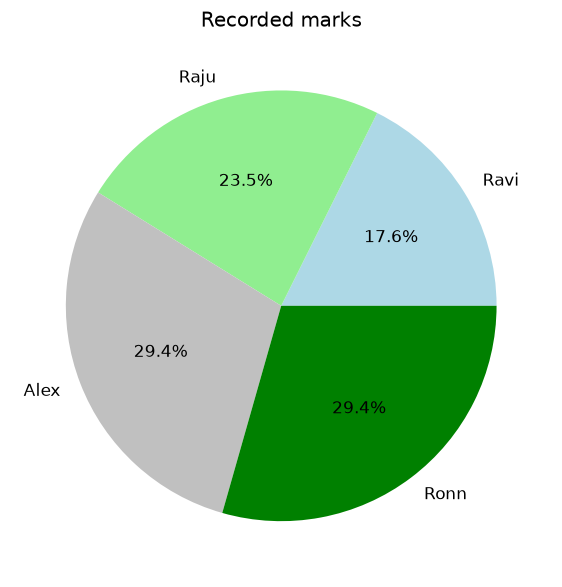

In [ ]:
df = student_data().set_index("NAME")
my_colors = ["lightblue", "lightgreen", "silver", "green"]
ax = df.plot.pie(y="MATH", colors=my_colors, legend=False,
                 autopct="%1.1f%%", figsize=(5, 5), title="Recorded marks")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Highlight a Slice with explode

Each <code>explode</code> entry specifies the offset of a slice as a fraction of the radius. The tuple must have one entry per slice. Small offsets draw attention without disrupting the comparison. Very large offsets such as 1.5 separate a slice by more than a radius and make the chart harder to read.

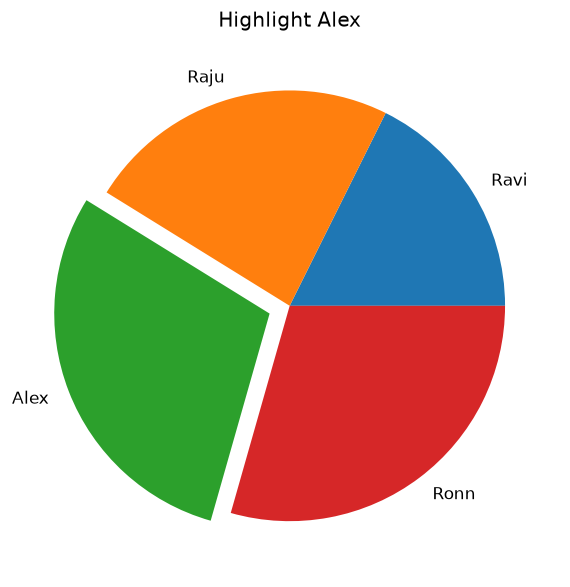

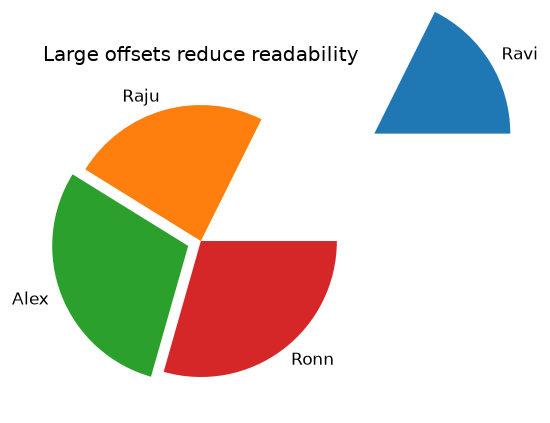

In [ ]:
df = student_data().set_index("NAME")
my_explode = (0, 0, 0.1, 0)
ax = df.plot.pie(y="MATH", explode=my_explode, legend=False,
                 figsize=(5, 5), title="Highlight Alex")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

# Compare a deliberately large offset to understand the option.
ax = df.plot.pie(y="MATH", explode=(1.5, 0, 0.1, 0), legend=False,
                 figsize=(5, 5), title="Large offsets reduce readability")
plt.tight_layout()
plt.show()

## Set startangle and Drawing Direction

<code>startangle</code> rotates the first slice from the positive horizontal axis. <code>counterclock=True</code> draws in the default counterclockwise direction; False draws clockwise. These options change arrangement, not the values or percentages.

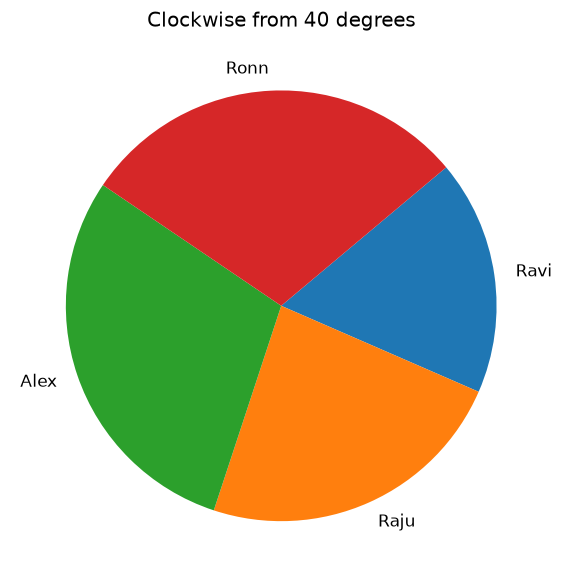

In [ ]:
df = student_data().set_index("NAME")
ax = df.plot.pie(y="MATH", startangle=40, counterclock=False,
                 legend=False, figsize=(5, 5), title="Clockwise from 40 degrees")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## rotatelabels, shadow and frame

<code>rotatelabels=True</code> rotates category text with the slice direction; it can make labels harder to read. <code>shadow=True</code> adds a shadow, while <code>frame=True</code> shows the axes frame. A simple flat chart without rotated labels is usually easier to read. The example demonstrates all three controls so you can compare them.

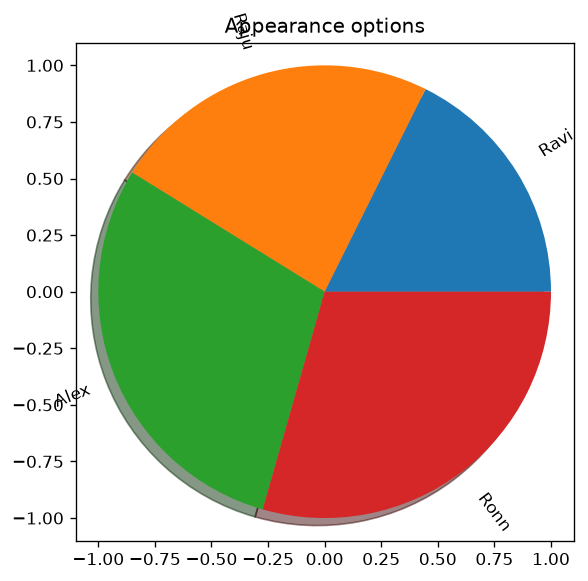

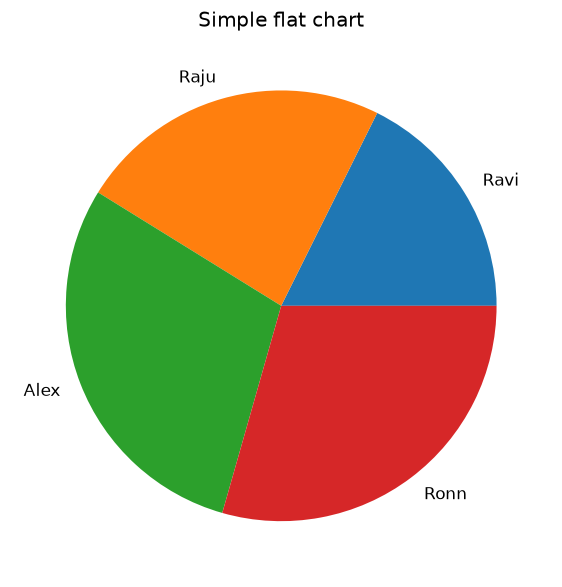

In [ ]:
df = student_data().set_index("NAME")
ax = df.plot.pie(y="MATH", rotatelabels=True, shadow=True, frame=True,
                 legend=False, figsize=(5, 5), title="Appearance options")
plt.tight_layout()
plt.show()

ax = df.plot.pie(y="MATH", rotatelabels=False, shadow=False, frame=False,
                 legend=False, figsize=(5, 5), title="Simple flat chart")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Practical Sales Example: Summarise Categories First

Pandas plots one slice per row, so repeated categories should be grouped before plotting. This synthetic dataset uses the same sales values as the <a href="https://www.plus2net.com/python/pandas-dataframe-plot-bar.php">bar-chart tutorial</a>. The category totals are parts of one recorded revenue total and use the same units.

In [ ]:
def sales_data():
    return pd.DataFrame({
        "category": ["Stationery", "Office", "Books", "Stationery", "Office", "Books"],
        "channel": ["Online", "Online", "Online", "Store", "Store", "Store"],
        "revenue": [120, 300, 180, 80, 250, 220]
    })

sales = sales_data()
totals = sales.groupby("category")["revenue"].sum().sort_values(ascending=False)
report = totals.to_frame("revenue")
report["share_percent"] = totals.div(totals.sum()).mul(100).round(1)
print(report)
assert totals.sum() == 1150
assert totals.to_dict() == {"Office": 550, "Books": 400, "Stationery": 200}

**Expected output**

```text
            revenue  share_percent
category                          
Office          550           47.8
Books           400           34.8
Stationery      200           17.4
```

## Plot Category Shares with a Clear Denominator

The title states that the pie represents recorded revenue. A supporting table provides exact amounts because similar-sized slices are hard to compare precisely. Use <a href="https://www.plus2net.com/python/pandas-dataframe-groupby.php">groupby()</a> and <a href="https://www.plus2net.com/python/pandas-dataframe-sum.php">sum()</a> to prepare the totals, then plot the Series.

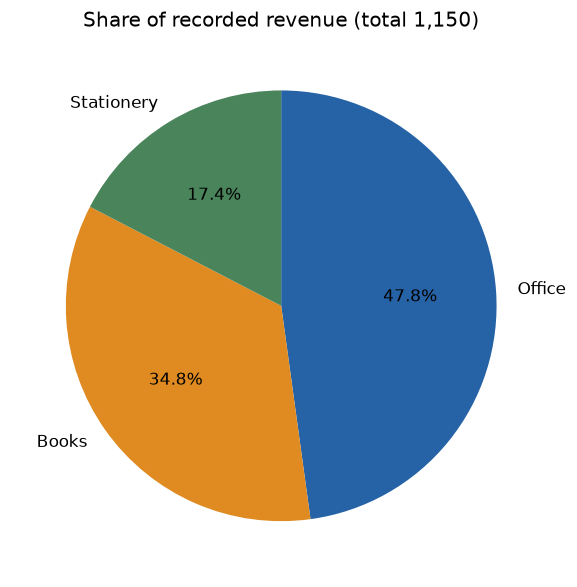

In [ ]:
sales = sales_data()
totals = sales.groupby("category")["revenue"].sum().sort_values(ascending=False)
palette = {"Office": "#2563a6", "Books": "#df8b22", "Stationery": "#49845b"}
ax = totals.plot.pie(colors=[palette[name] for name in totals.index],
                      autopct="%1.1f%%", startangle=90, counterclock=False,
                      legend=False, figsize=(6, 5),
                      title="Share of recorded revenue (total 1,150)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

**What to check:** Office 47.8%, Books 34.8% and Stationery 17.4%. See the rendered chart in the notebook.

## Validate Missing, Negative and Zero Values

A pie needs finite, non-negative values and a positive total. Unknown revenue must not silently become zero. Negative values, such as refunds, need a different report. Validate the plotted Series before charting; do not let an all-missing group become a zero total. For incomplete inputs, follow the <a href="https://www.plus2net.com/python/pandas-dataframe-fillna.php">missing-value guidance</a>.

In [ ]:
import numpy as np

def validate_pie_values(values):
    numeric = pd.to_numeric(values, errors="raise").astype("float64")
    if not np.isfinite(numeric.to_numpy()).all():
        raise ValueError("Pie values must be known and finite.")
    if numeric.lt(0).any():
        raise ValueError("Pie values cannot be negative.")
    if numeric.sum() <= 0:
        raise ValueError("Pie values need a positive total.")
    return numeric

for values in ([20, 30], [20, None], [20, -5], [0, 0]):
    try:
        checked = validate_pie_values(pd.Series(values))
        print("Valid total:", checked.sum())
    except ValueError as error:
        print(error)

**Expected output**

```text
Valid total: 50.0
Pie values must be known and finite.
Pie values cannot be negative.
Pie values need a positive total.
```

## Combine Small Categories Without Losing the Total

Too many slices make labels and proportions difficult to read. Combine smaller categories as Other under a stated rule, or use a <a href="https://www.plus2net.com/python/pandas-dataframe-plot-barh.php">horizontal bar chart</a>. Here the two largest categories are kept individually; the remainder becomes Other. Check that the displayed total matches the original.

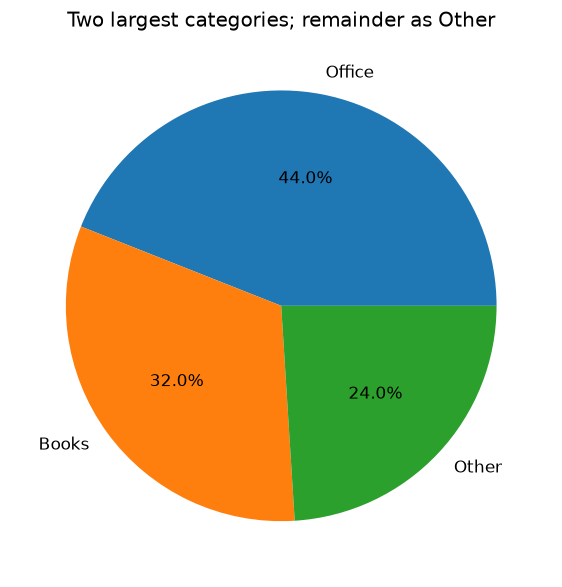

In [ ]:
amounts = pd.Series({"Office": 550, "Books": 400, "Stationery": 200,
                     "Accessories": 60, "Other supplies": 40})
ordered = validate_pie_values(amounts).sort_values(ascending=False)
display = pd.concat([ordered.iloc[:2],
                     pd.Series({"Other": ordered.iloc[2:].sum()})])
print(display)
assert display.sum() == amounts.sum()
ax = display.plot.pie(autopct="%1.1f%%", legend=False, figsize=(5, 5),
                       title="Two largest categories; remainder as Other")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

**Expected output**

```text
Office    550.0
Books     400.0
Other     300.0
dtype: float64
```

## Save Your Pie Chart as a PNG

Save the returned Axes figure before closing it. A relative filename works in Colab and on your computer. In Colab, download the file from the Files sidebar; saving in the runtime does not automatically copy it to Drive. See the <a href="https://www.plus2net.com/python/colab.php">Colab guide</a> for file handling.

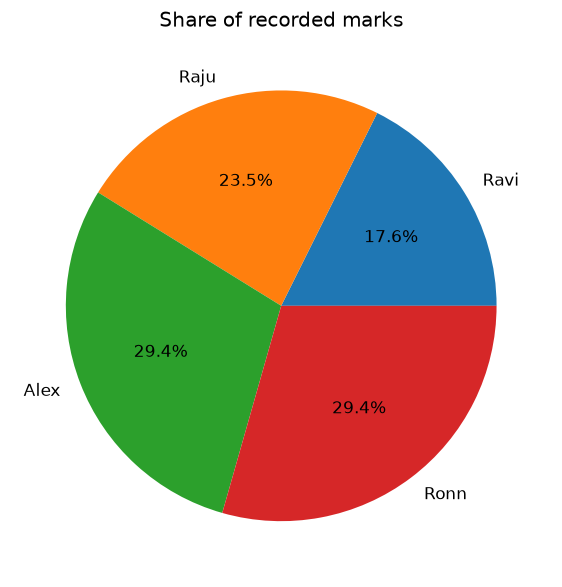

In [ ]:
df = student_data().set_index("NAME")
ax = df.plot.pie(y="MATH", autopct="%1.1f%%", legend=False,
                 figsize=(5, 5), title="Share of recorded marks")
ax.set_ylabel("")
plt.tight_layout()
fig = ax.get_figure()
fig.savefig("pandas_pie_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved pandas_pie_chart.png")

**Expected output**

```text
Saved pandas_pie_chart.png
```

## When a Bar Chart Is a Better Choice

Use a pie for a few mutually exclusive, non-negative parts of a meaningful whole. Use <a href="https://www.plus2net.com/python/pandas-dataframe-plot-bar.php">bars</a> for exact category comparisons, similar values, negative values or multiple series. Use <a href="https://www.plus2net.com/python/pandas-dataframe-plot-line.php">lines</a> to show change over time. Do not put quantities, prices and revenue into one pie: their units do not form a common whole. Multiple pies each normalise to their own total, so they can hide large differences in size.

## Exercise: Revenue Share by Channel

Group the sales data by channel and plot the Online and Store shares with one-decimal percentage labels. Predict the denominator and both percentages. Expected total: 1,150; Online 52.2%, Store 47.8%.

## Exercise Solution

The channel totals are mutually exclusive parts of the same recorded revenue. Validate them before plotting, and check that the two totals add up to the source revenue.

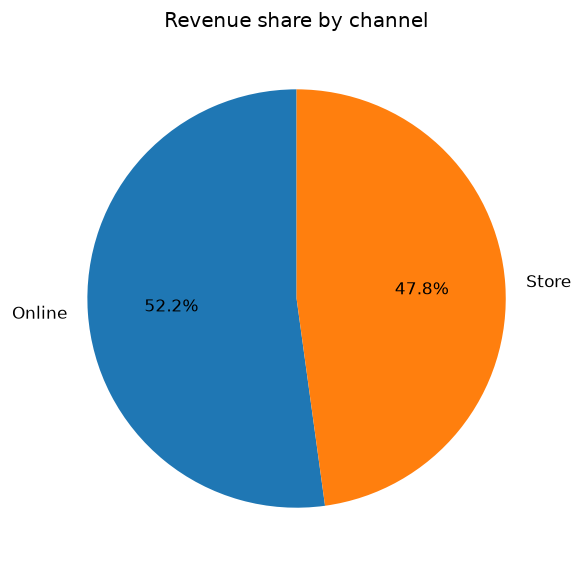

In [ ]:
sales = sales_data()
totals = validate_pie_values(sales.groupby("channel")["revenue"].sum())
print(totals)
print(totals.div(totals.sum()).mul(100).round(1))
assert totals.to_dict() == {"Online": 600, "Store": 550}
assert totals.sum() == sales["revenue"].sum()
ax = totals.plot.pie(autopct="%1.1f%%", startangle=90,
                      legend=False, figsize=(5, 5), title="Revenue share by channel")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

**Expected output**

```text
channel
Online    600.0
Store     550.0
Name: revenue, dtype: float64
channel
Online    52.2
Store     47.8
Name: revenue, dtype: float64
```

## Practice in Google Colab

<a class="btn btn-outline-primary" href="https://colab.research.google.com/github/plus2net/pandas/blob/main/pandas_pie_chart_practice.ipynb" target="_blank" rel="noopener">Open in Google Colab</a> <a class="btn btn-outline-secondary" href="https://github.com/plus2net/pandas/blob/main/pandas_pie_chart_practice.ipynb" target="_blank" rel="noopener">View on GitHub</a><br>All datasets and rendered example charts are included. Run the cells, adjust the options and try the exercise. Save a copy in Drive to keep your changes.